# Tutorial to pull data from the [DESI Legacy survey](https://www.legacysurvey.org/) and fit it

### 1. Download the data

In [1]:
import requests
from tqdm import tqdm
import os

def get_file(pos:tuple, size:int=512, pixscale:float=0.262, band:str="i", savefolder:str="data/"):
    """
    Download images from the DESI Legacy survey to your local machine.

    pos : (ra,dec) in decimal degrees
    size : size of one side of the image you want to download, in pixels
    pixscale : the arcsecond/pixel ratio you want in the downloaded image. The real one is 0.262, so it's best not to modify it.
    band : the string representing which band you want to download (choose between g,r,i, and z) !!!Only use one at a time, each band has its own PSF!!!
    savefolder : path of the directory you want to download the data to.
    """
    ra, dec = pos
    if not os.path.exists(savefolder): # Create the savefolder if it doesn't already exist.
        os.makedirs(savefolder)
    # Get the sky image
    url = f'https://www.legacysurvey.org/viewer/fits-cutout?ra={str(ra)}&dec={str(dec)}&size={size}&layer=ls-dr10&pixscale={pixscale}&bands={band}&invvar'
    r = requests.get(url)
    open(f"{savefolder}sky_{band}.fits" , 'wb').write(r.content)
    # Get the PSF image
    url = f'https://www.legacysurvey.org/viewer/coadd-psf/?ra={str(ra)}&dec={str(dec)}&layer=ls-dr10&bands={band}'
    r = requests.get(url)
    open(f"{savefolder}PSF_{band}.fits" , 'wb').write(r.content)

/Users/oliviergilbert/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In order to download all the data for a single object, loop ```get_file``` over the different bands.

In [2]:
pos = (19.7861250,-34.1916944) # Example RA and DEC of GSN 069
for band in "griz":
    get_file(pos, size=512, pixscale=0.262, band=band, savefolder="data/GSN069/")

### 2. Fit the data

Fit the downloaded data using ```fit_object()```. Read the function description for a description of the parameters. Most of the parameters are not meant to be changed between each object as it should generally work with the default values. It is possible to customize this function even further by directly changing the code inside of it that is not affected by the arguments. For example, it is possible to set up manual bounds for some parameters, fixing parameters, etc. by adding options in ```prepare_fitting_seq()```.

In [3]:
import numpy as np
import astropy.io.fits as pyfits
import galight.tools.astro_tools as astro_tools
from galight_modif.data_process import DataProcess
from galight_modif.fitting_specify import FittingSpecify
from galight_modif.fitting_process import FittingProcess
import copy
import lenstronomy.Util.param_util as param_util

In [4]:
def fit_object(pos:tuple, img_path:str, psf_path:str=None, additional_components:str="AGN", pixel_scale:float=0.262, band:str="g", nsigma:int=15, radius:int=60, exp_sz_multiplier:float=1, npixels:int=5, savefolder:str="data/", threshold:float=5, fitting_level:str="deep", fixed_n_list:list=None, if_plot:bool=False):
    """
    Fit an image with a 2D Sérsic model and optional additional components.

    pos : (ra,dec) in decimal degrees
    img_path : str pointing to your sky_X.fits image, where X is the band.
    psf_path : str pointing to your PSF_X.fits image, where X is the band.
    additional_components : str representing which components you want to fit on top of the default Sérsic. Choices are: ["AGN","BULGE","BULGE_FIXED","BULGE+AGN"]
    pixel_scale : the arcsecond/pixel ratio of the downloaded image. The default one is 0.262.
    band : the string representing which band you want to fit (choose between g,r,i, and z)
    nsigma : int to choose the number of sigmas needed for a source in the sky image to be considered significant (non-background).
    radius : int representing the size (in pixels) of the cutout that will be kept of the original sky_X.fits image for the fitting.
    exp_sz_multiplier : float, optional tweak option to change the size of the detected source(s) for the modelling/masking. Leaving it at 1 usually works.
    npixels : int, minimum number of pixels that a source must span to be considered a source.
    savefolder : path of the directory you want to download the data to (plots+.pkl).
    threshold : float, determines how sensitive the program is to find PSF stars in the sky_X.fits image. Only relevant if no psf_path is provided.
    fitting_level : str, option to choose how long the PSO and the MCMC will run, usually resulting in better fits the longer it runs. Options are ["shallow","deep","mega_deep","giga_deep","paper_deep"]
    fixed_n_list : list, option to fix the Sérsic index of the various sources. (e.g., to fix the Sérsic index of the first source at 2.09: [[0,2.09]])
    if_plot : bool, flag if you want the code to plot the figures or calculate everything silently.
    """
    if additional_components is None:
        number_of_ps = 0
        bulge = False
    elif additional_components.upper() == "AGN":
        number_of_ps = 1
        bulge = False
    elif additional_components.upper() in ["BULGE", "BULGE_FIXED"]:
        number_of_ps = 0
        bulge = True
    elif additional_components.upper() in ["BULGE+AGN", "AGN+BULGE"]:
        number_of_ps = 1
        bulge = True
    else:
        raise ValueError(f"{additional_components} is not a supported fitting type")
    if band not in "griz":
        raise ValueError(f"band {band} is not a supported filter band")

    img = pyfits.open(img_path)
    fov_noise_map = None
    zp = 22.5
    fov_image = (img[0].data) #[:,:,band_index]
    header = img[0].header
    exp =  1
    exp_map = exp
    wht = img[1].data
    mean_wht = exp * (pixel_scale)**2  #The drizzle information is used to derive the mean WHT value.
    exp_map = exp * wht/mean_wht  #Derive the exposure time map for each pixel
    fov_noise_map = 1/np.sqrt(wht)


    data_process = DataProcess(fov_image = fov_image, target_pos = [pos[0], pos[1]], pos_type = 'wcs', header = header,
                            rm_bkglight = True, exptime = exp_map, if_plot=if_plot, zp = zp, fov_noise_map=fov_noise_map, mp=True)

    data_process.generate_target_materials(radius=radius, create_mask = True, nsigma=nsigma,
                                        exp_sz= exp_sz_multiplier, npixels = npixels, if_plot=if_plot, show_materials=False)

    #Create a dictionnary of all informations that could be useful for us
    coolinfos = data_process.arguments.copy()
    coolinfos["cutout_radius"] = radius
    coolinfos["pix_scale"] = pixel_scale
    print('---------------DATA PROCESS PARAMETERS-------------')
    print('target_pos:', data_process.target_pos)
    print('zero point:', data_process.zp) #zp is in the AB system and should be 22.5: https://www.legacysurvey.org/svtips/
    print('kwargs: ', data_process.arguments)
    print('---------------------------------------------------')

    if psf_path == None:
        data_process.find_PSF(radius = 30, user_option = True, threshold=threshold)  #Try this line out!
        data_process.psf_id_for_fitting = 0
    else:
        psf_img = pyfits.open(psf_path)[0].data
        fwhm = data_process.use_custom_psf(psf_img, if_plot=if_plot)
        print(f'FWHM = {np.around(fwhm*pixel_scale, decimals=3)}"')

    #Check if all the materials is given, if so to pass to the next step.
    data_process.checkout()

    if bulge:
        apertures = copy.deepcopy(data_process.apertures)
        comp_id = 0
        add_aperture0 = copy.deepcopy(apertures[comp_id])
        #This setting assigns comp0 as 'bulge' and comp1 as 'disk'
        add_aperture0.a, add_aperture0.b = add_aperture0.a/2, add_aperture0.b/2
        apertures = apertures[:comp_id] + [add_aperture0] + apertures[comp_id:]
        data_process.apertures = apertures #Pass apertures to the data_process

        #Adding a condition so that 1)the size of the bulge is within a reasonable radius range compared to the disk radius. 2) the disk component has a higher ellipticity than the bulge.
        def condition_bulgedisk(kwargs_lens, kwargs_source, kwargs_lens_light, kwargs_ps, kwargs_special, kwargs_extinction):
            logL = 0
            #note that the Comp[0] is the bulge and the Comp[1] is the disk.
            phi0, q0 = param_util.ellipticity2phi_q(kwargs_lens_light[0]['e1'], kwargs_lens_light[0]['e2'])
            phi1, q1 = param_util.ellipticity2phi_q(kwargs_lens_light[1]['e1'], kwargs_lens_light[1]['e2'])
            cond_0 = (kwargs_lens_light[0]['R_sersic'] > kwargs_lens_light[1]['R_sersic'] * 0.9)
            cond_1 = (kwargs_lens_light[0]['R_sersic'] < kwargs_lens_light[1]['R_sersic']*0.15)
            cond_2 = (q0 < q1)
            if cond_0 or cond_1 or cond_2:
                logL -= 10**15
            return logL
    else:
        condition_bulgedisk = None

    #PREPARE THE FITTING
    fit_sepc = FittingSpecify(data_process)
    
    #Prepare the fitting sequence, keywords see notes above.
    fit_sepc.prepare_fitting_seq(point_source_num = number_of_ps,
                                fix_Re_list=None,
                                fix_n_list=fixed_n_list, #To fix the Sérsic index at 2.09: [[0,2.09]]
                                fix_center = None,
                                fix_ellipticity = None,
                                manual_bounds = None, #{'lower':{'e1': -0.5, 'e2': -0.5, 'R_sersic': 0.01, 'n_sersic': 2., 'center_x': 0, 'center_y': 0},
                                                #'upper':{'e1': 0.5, 'e2': 0.5, 'R_sersic': 5, 'n_sersic': 9., 'center_x': 0, 'center_y': 0}},
                                condition=condition_bulgedisk)


    #Build up and to pass to the next step.
    fit_sepc.build_fitting_seq()
    #Pass fit_sepc to FittingProcess,
    fit_run = FittingProcess(fit_sepc, savename = savefolder, fitting_level=fitting_level) 
    #Setting the fitting approach and Run:
    fit_run.run(algorithm_list = ['PSO', 'MCMC'], setting_list = None)
    fit_run.mcmc_result_range()
    # Plot all the fitting results:
    fit_run.plot_all(target_ID=f'{str(pos[0])+str(pos[1])}-{band}', show_plot=if_plot, save_plot=True)
    fit_run.coolinfos = coolinfos
    #Save the fitting class as pickle format:
    fit_run.dump_result(savefolder=savefolder)

Use this function to fit the example above:

target_pos (wcs) [19.786125, -34.1916944]
target pos: [256.5 256.5]
0.26200000000000007 0.26200000000000007
0.0
Estimating the background light ... ... ...


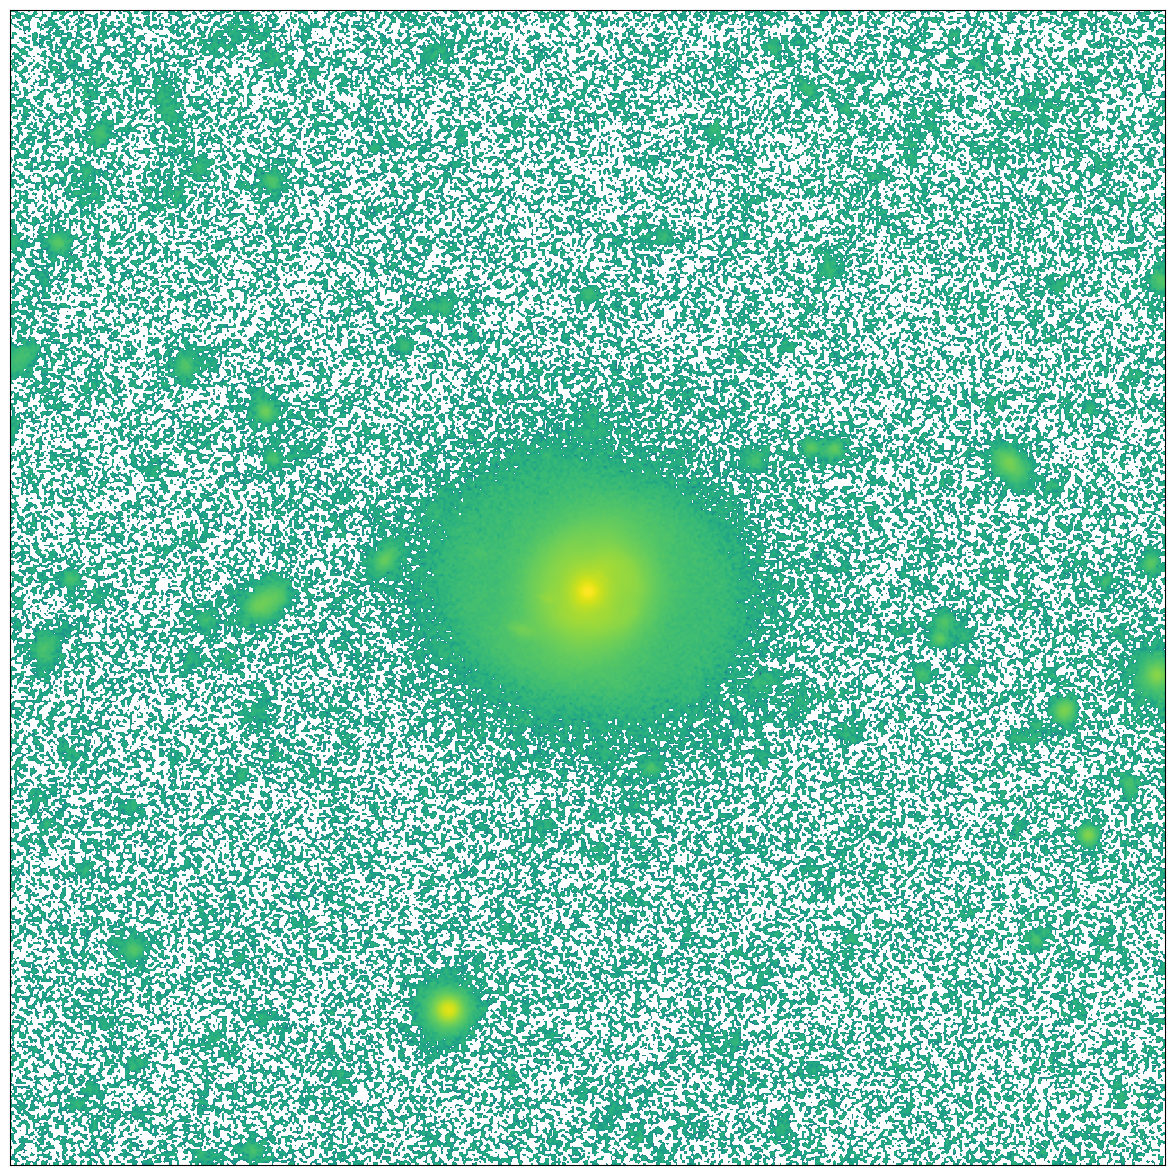

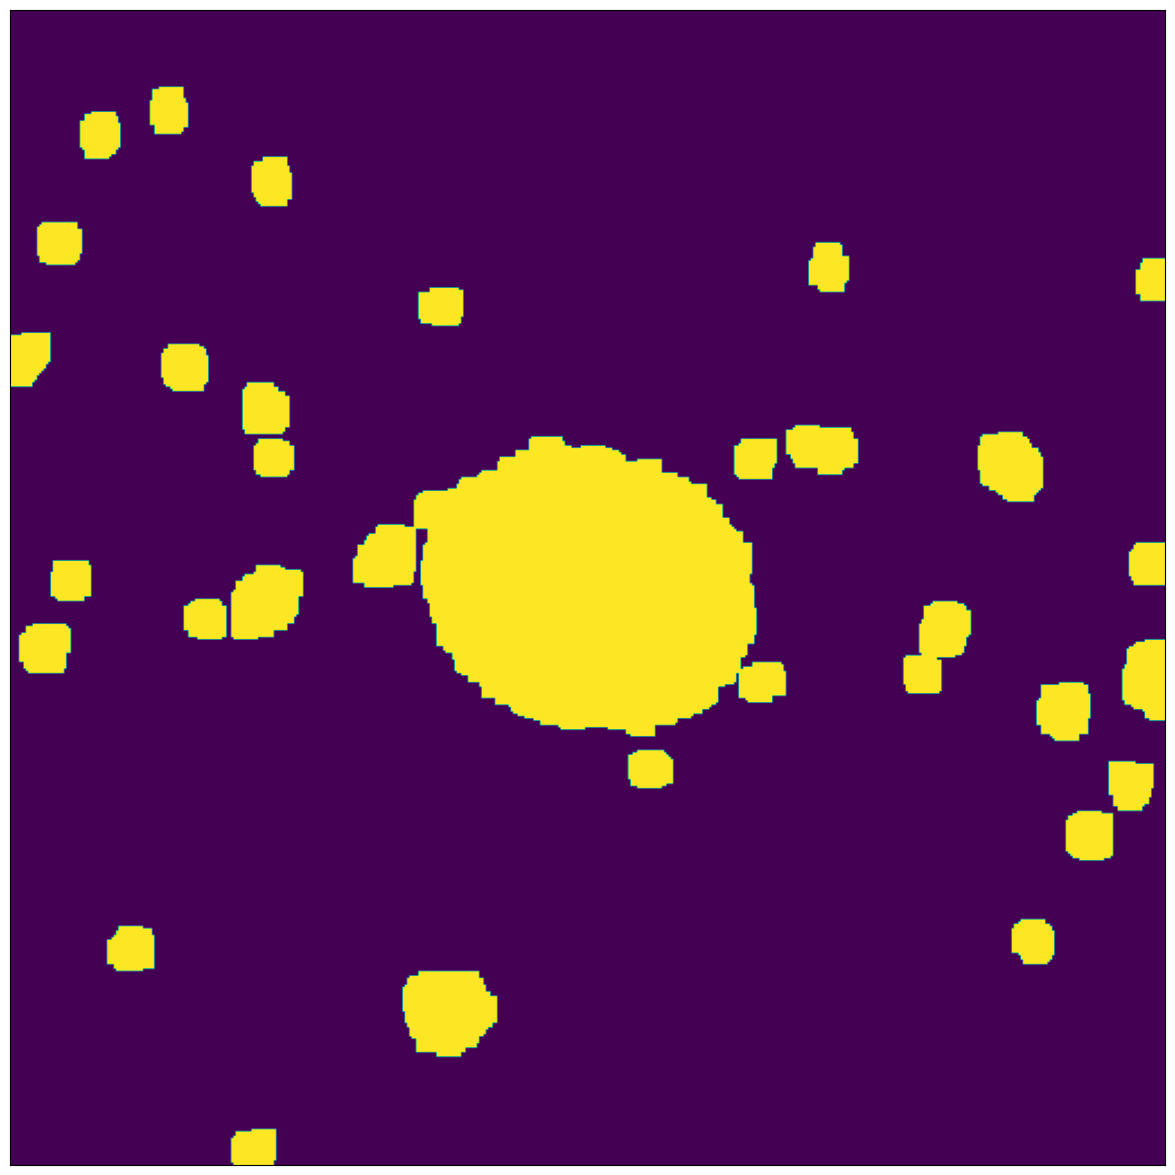

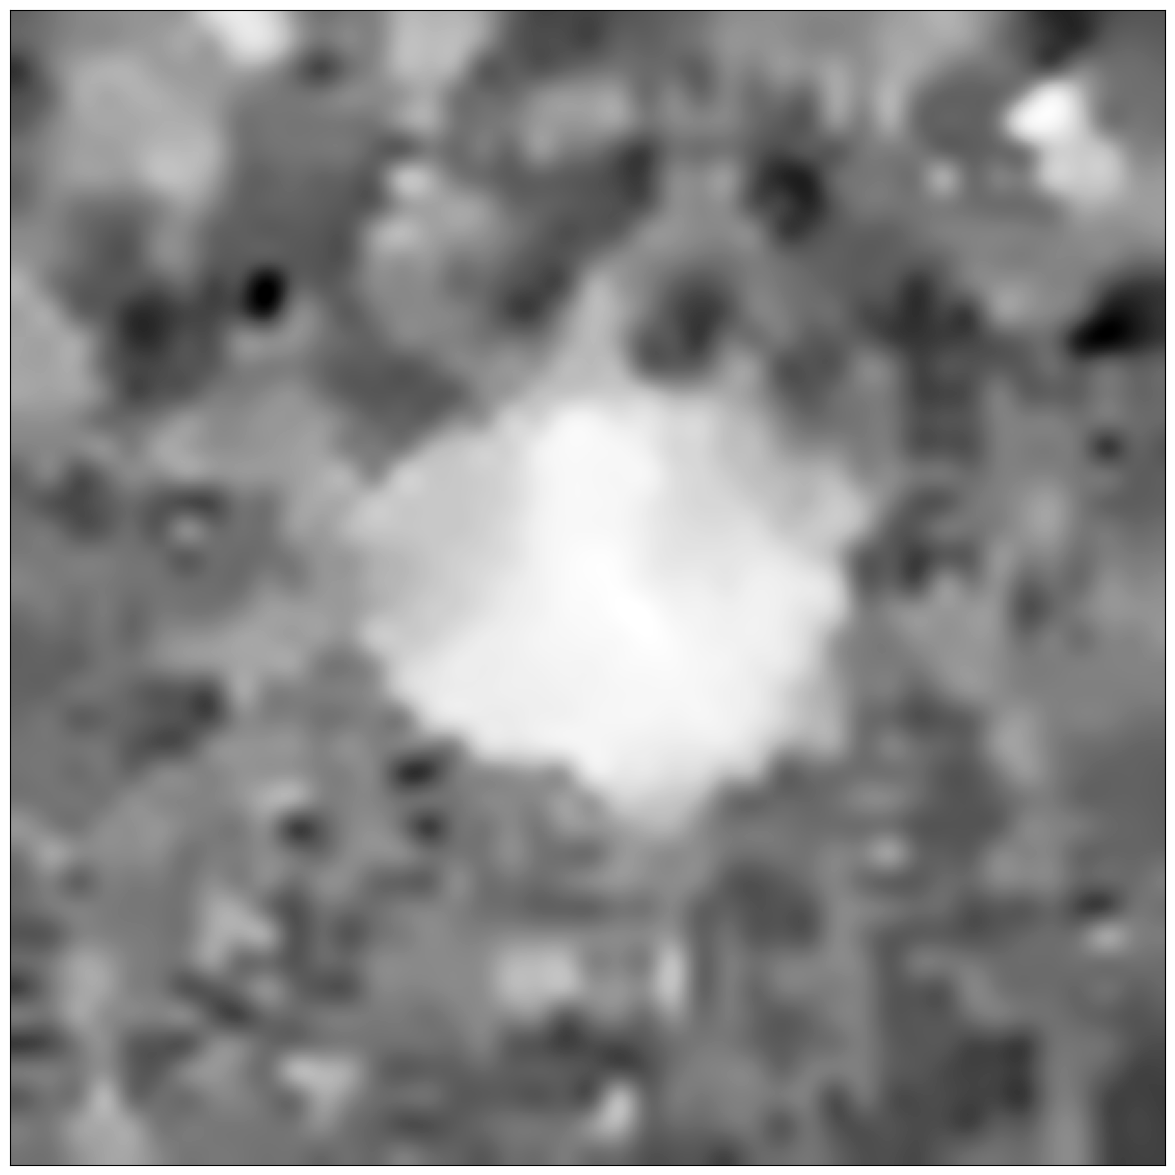

Deblending:   0%|          | 0/3 [00:00<?, ?it/s]

(0.0018087588, 3.065478e-05)


Deblending:   0%|          | 0/3 [00:00<?, ?it/s]

Deblending:   0%|          | 0/1 [00:00<?, ?it/s]

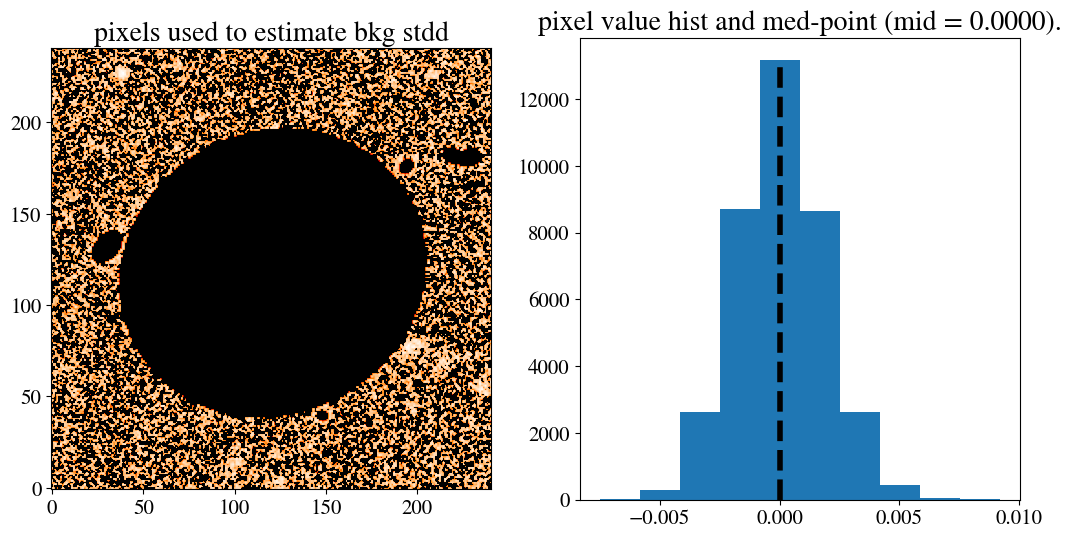

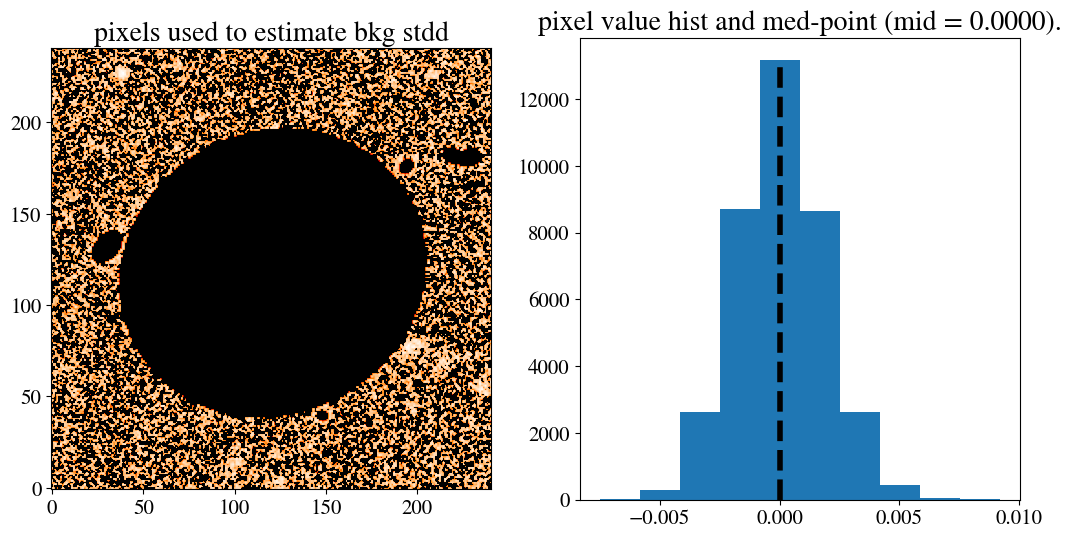

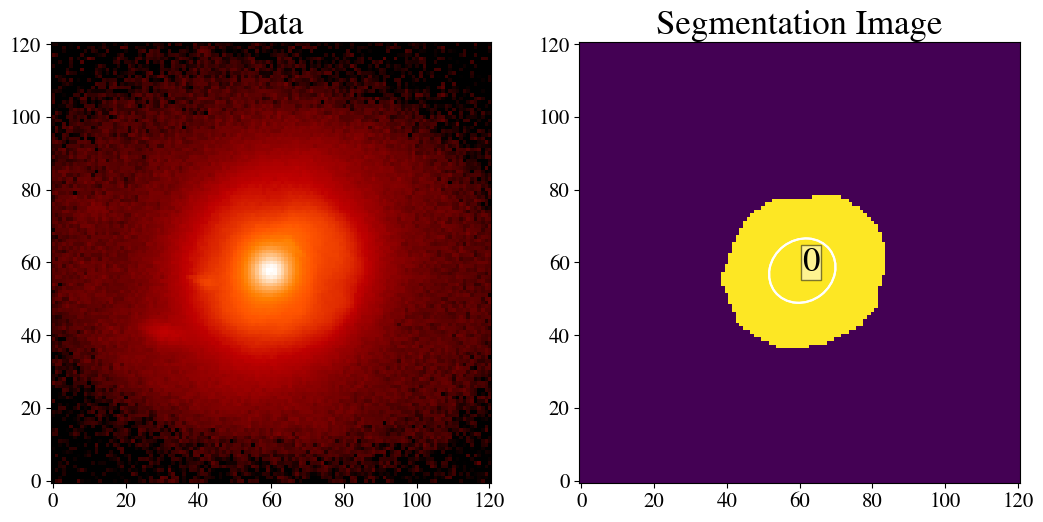

---------------DATA PROCESS PARAMETERS-------------
target_pos: [256 256]
zero point: 22.5
kwargs:  {'nsigma': 15, 'exp_sz': 1, 'npixels': 5}
---------------------------------------------------


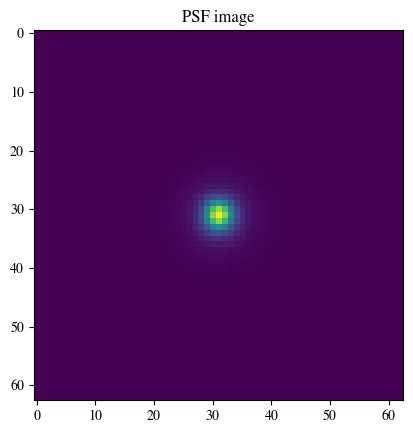

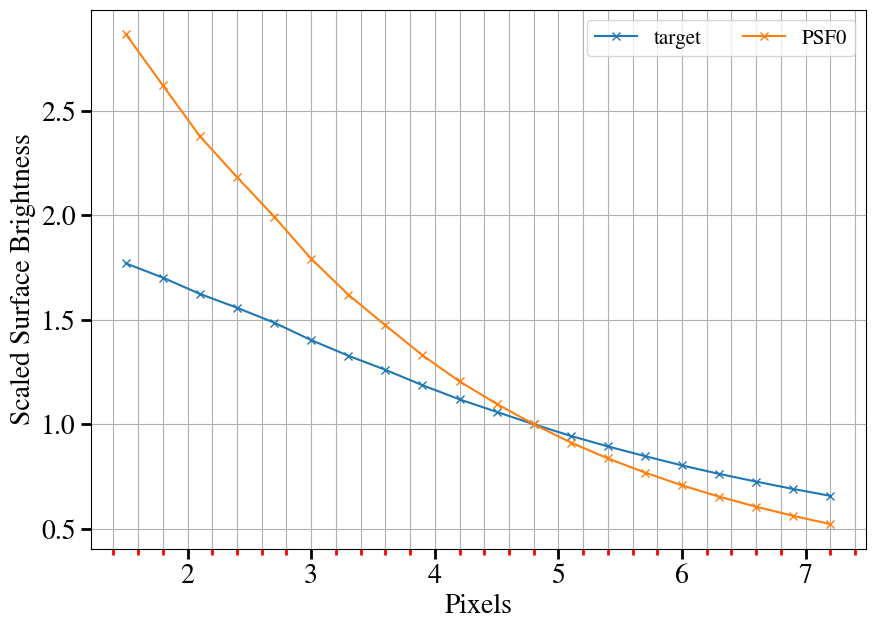

FWHM = 1.13"
The negative PSF values are corrected as 0 values.
The data_process is ready to go to pass to FittingSpecify!
The settings for the fitting is done. Ready to pass to FittingProcess. 
  However, please make updates manullay if needed.
******************************************
kwargs_model fitSeq  {'point_source_model_list': ['UNLENSED'], 'lens_light_model_list': ['SERSIC_ELLIPSE'], 'sersic_major_axis': True}
kwargs_model {'point_source_model_list': ['UNLENSED'], 'lens_light_model_list': ['SERSIC_ELLIPSE'], 'sersic_major_axis': True}
******************************************
kwargs_model fitSeq  {'point_source_model_list': ['UNLENSED'], 'lens_light_model_list': ['SERSIC_ELLIPSE'], 'sersic_major_axis': True}
kwargs_model {'point_source_model_list': ['UNLENSED'], 'lens_light_model_list': ['SERSIC_ELLIPSE'], 'sersic_major_axis': True}
Start fit_sequence()


/Users/oliviergilbert/Desktop/QPEs/QPEs/galight_modif/fitting_specify.py:187: UserWarning: 
  warnings.warn("\nWarning: could not find the enough number of local max to match the PS numbers. Thus, all the initial PS set the same initial parameters.")


kwargs_temp {'kwargs_lens': [], 'kwargs_source': [], 'kwargs_lens_light': [{'R_sersic': 2.487290297018922, 'n_sersic': 2.0, 'e1': 0.015165530084207577, 'e2': -0.05674251150111202, 'center_x': -0.1969297387248897, 'center_y': -0.5963509006575541}], 'kwargs_ps': [{'ra_image': [-0.13100000000000003], 'dec_image': [0.13100000000000003]}], 'kwargs_special': {}, 'kwargs_extinction': [], 'kwargs_tracer_source': []}
Computing the PSO ...
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
Max iteration reached! Stopping.
-9.895845564961549 reduced X^2 of best position
-72393.0582304762 log likelihood
14631.0 effective number of data points
[] lens result
[] source result
[{'amp': 1, 'R_sersic': 4.494496931454574, 'n_sersic': 2.5717032710665477, 'e1': -0.01901983132490101, 'e2': -0.08397661769105527, 'center_x': -0.04448867870221246, 'center_y': -0.7042732864004935}] lens light result
[{'ra_image': array([0.1324915]), 'dec_image': array([-0.39299999]), 'point_amp': array([1.])}] point source res

100%|██████████| 300/300 [00:45<00:00,  6.66it/s]


Computing the MCMC...
Number of walkers =  80
Burn-in iterations:  100
Sampling iterations (in current run): 300
45.24482202529907 time taken for MCMC sampling
Stop fit_sequence()
Start getting best_fit()
{'kwargs_lens': [], 'kwargs_source': [], 'kwargs_lens_light': [{'amp': 1, 'R_sersic': 4.430734343090647, 'n_sersic': 2.466487099551285, 'e1': -0.018611053608140773, 'e2': -0.08388861895452518, 'center_x': -0.06478903184899155, 'center_y': -0.7202564839792865}], 'kwargs_ps': [{'ra_image': array([0.13689419]), 'dec_image': array([-0.39274793]), 'point_amp': array([1.])}], 'kwargs_special': {}, 'kwargs_extinction': [], 'kwargs_tracer_source': []}
Stop getting best_fit()
*************************************
BIC: 144769.0877510364
63.965 total time taken for the overall fitting (s)
============ CONGRATULATION, YOUR JOB WAS SUCCESSFUL ================ 
ini Source result: [{'amp': 1, 'R_sersic': 4.430734343090647, 'n_sersic': 2.466487099551285, 'e1': -0.018611053608140773, 'e2': -0.08388861

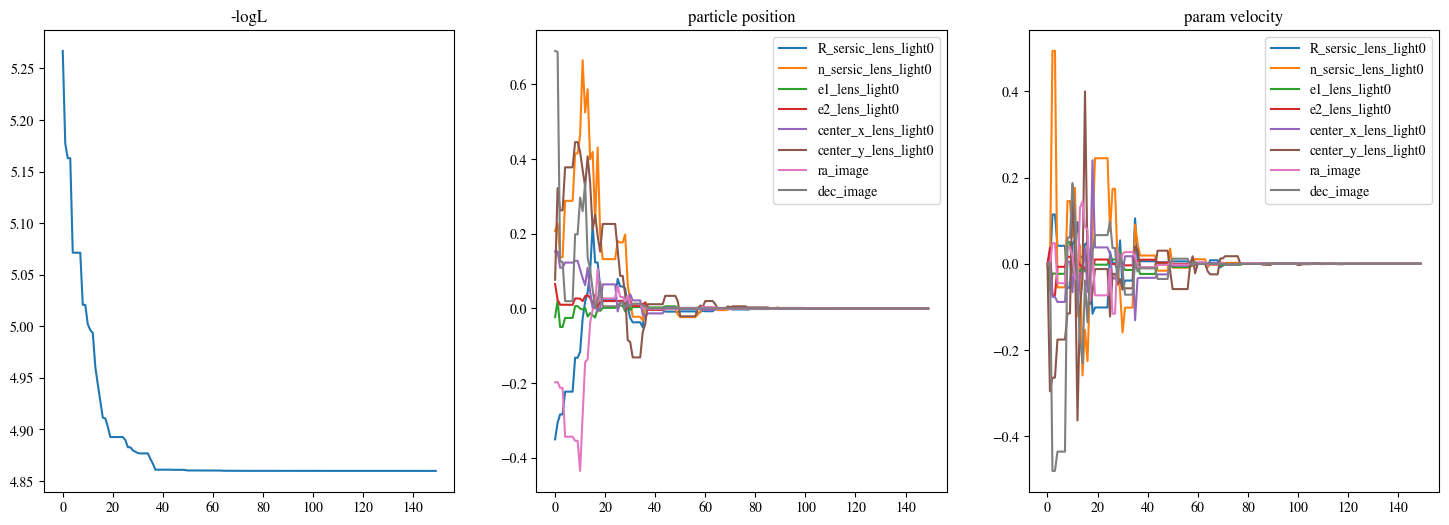

<Figure size 640x480 with 0 Axes>

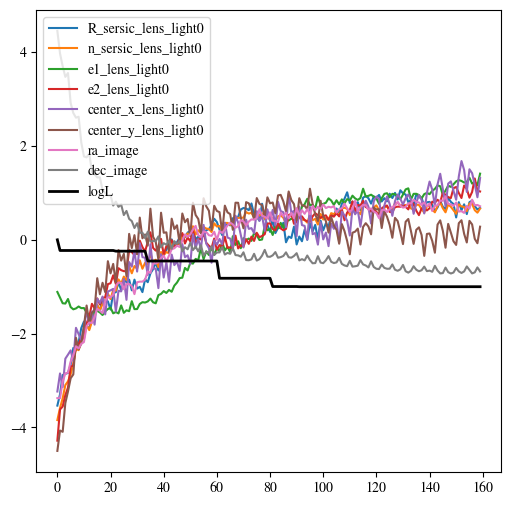

-9.88137230654494 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  9.88137230654494


/Users/oliviergilbert/Library/Python/3.9/lib/python/site-packages/lenstronomy/Plots/model_band_plot.py:160: RuntimeWarning: invalid value encountered in log10
  np.log10(self._data),
/Users/oliviergilbert/Library/Python/3.9/lib/python/site-packages/lenstronomy/Plots/model_band_plot.py:1157: RuntimeWarning: invalid value encountered in log10
  np.log10(self._data - model),


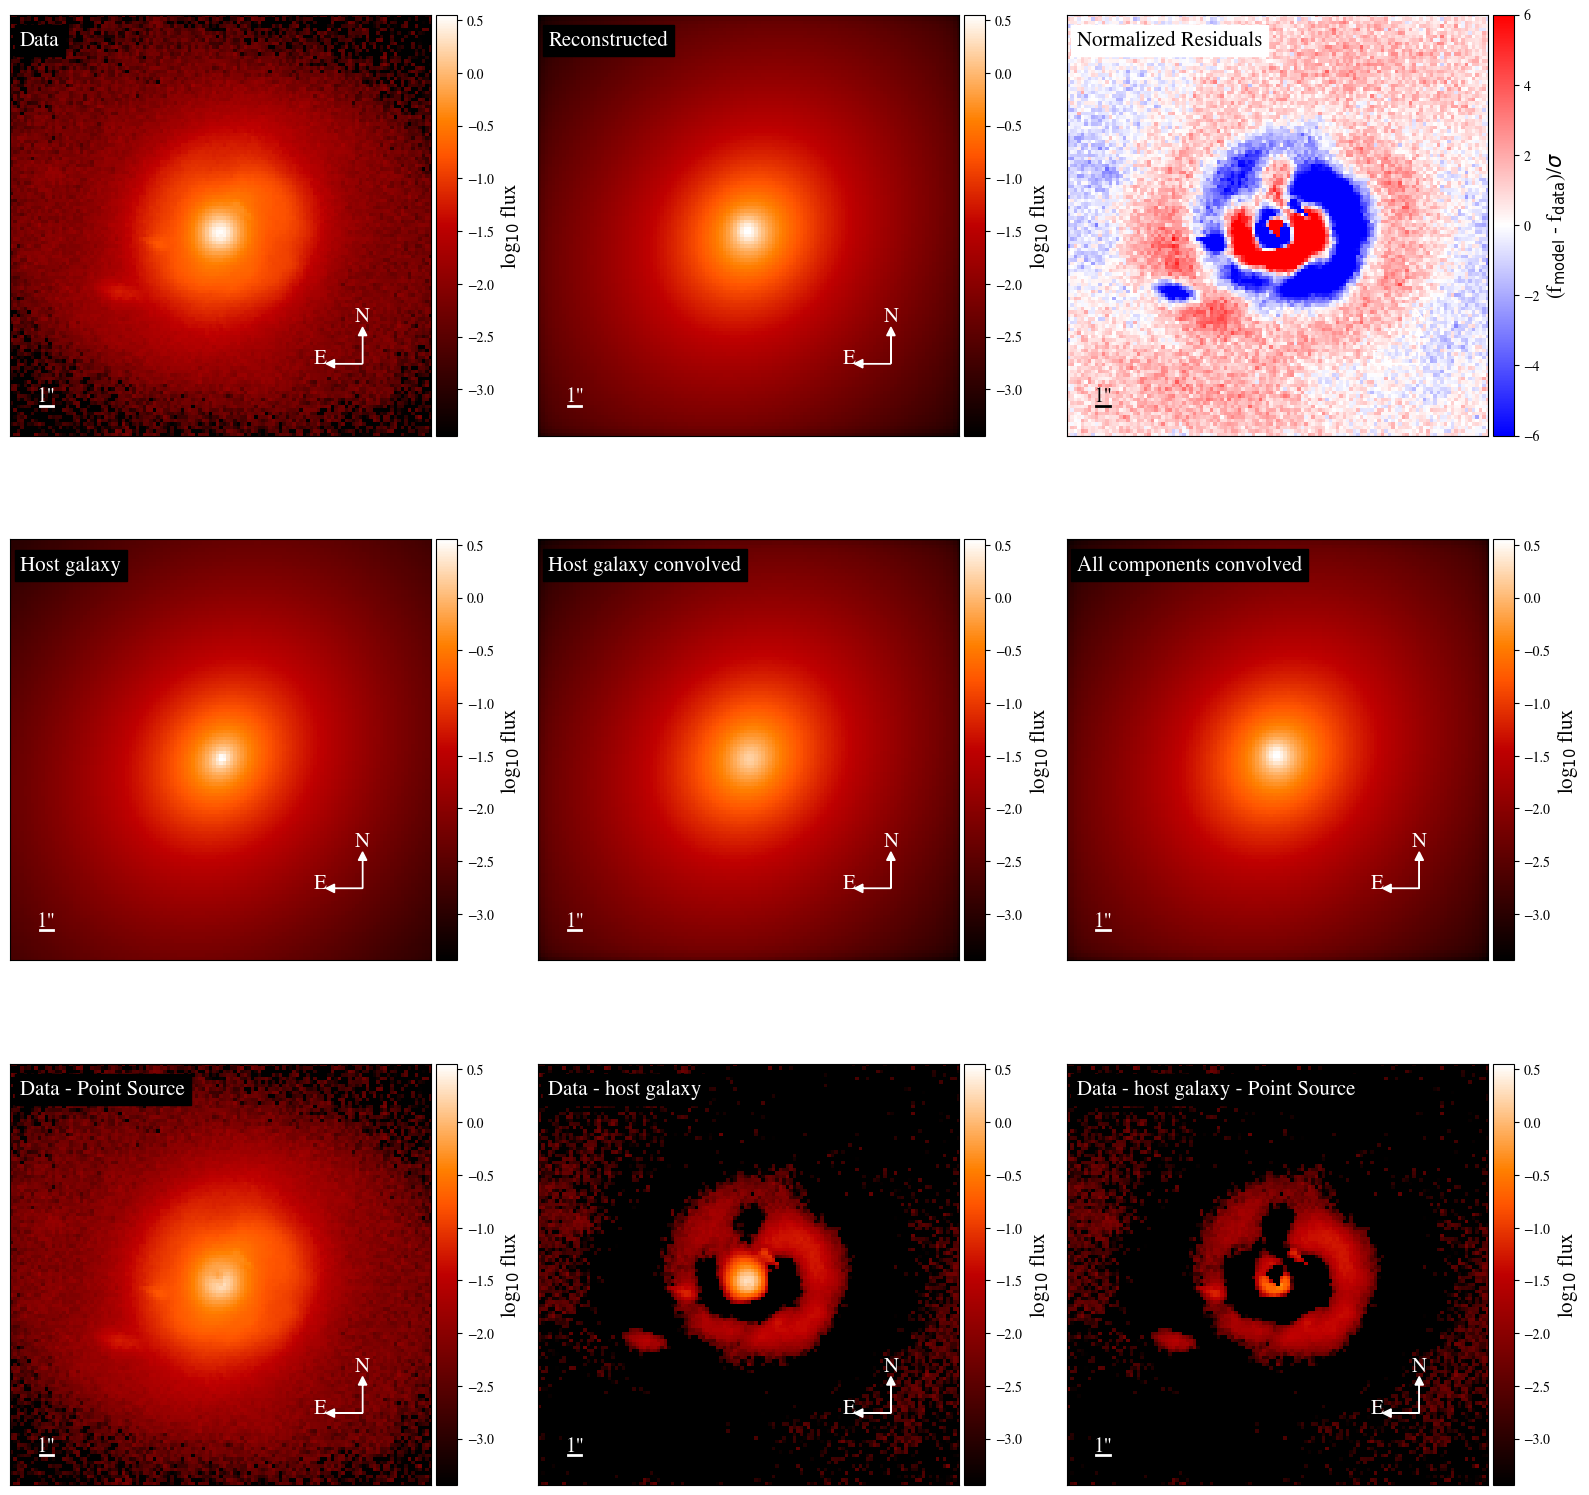

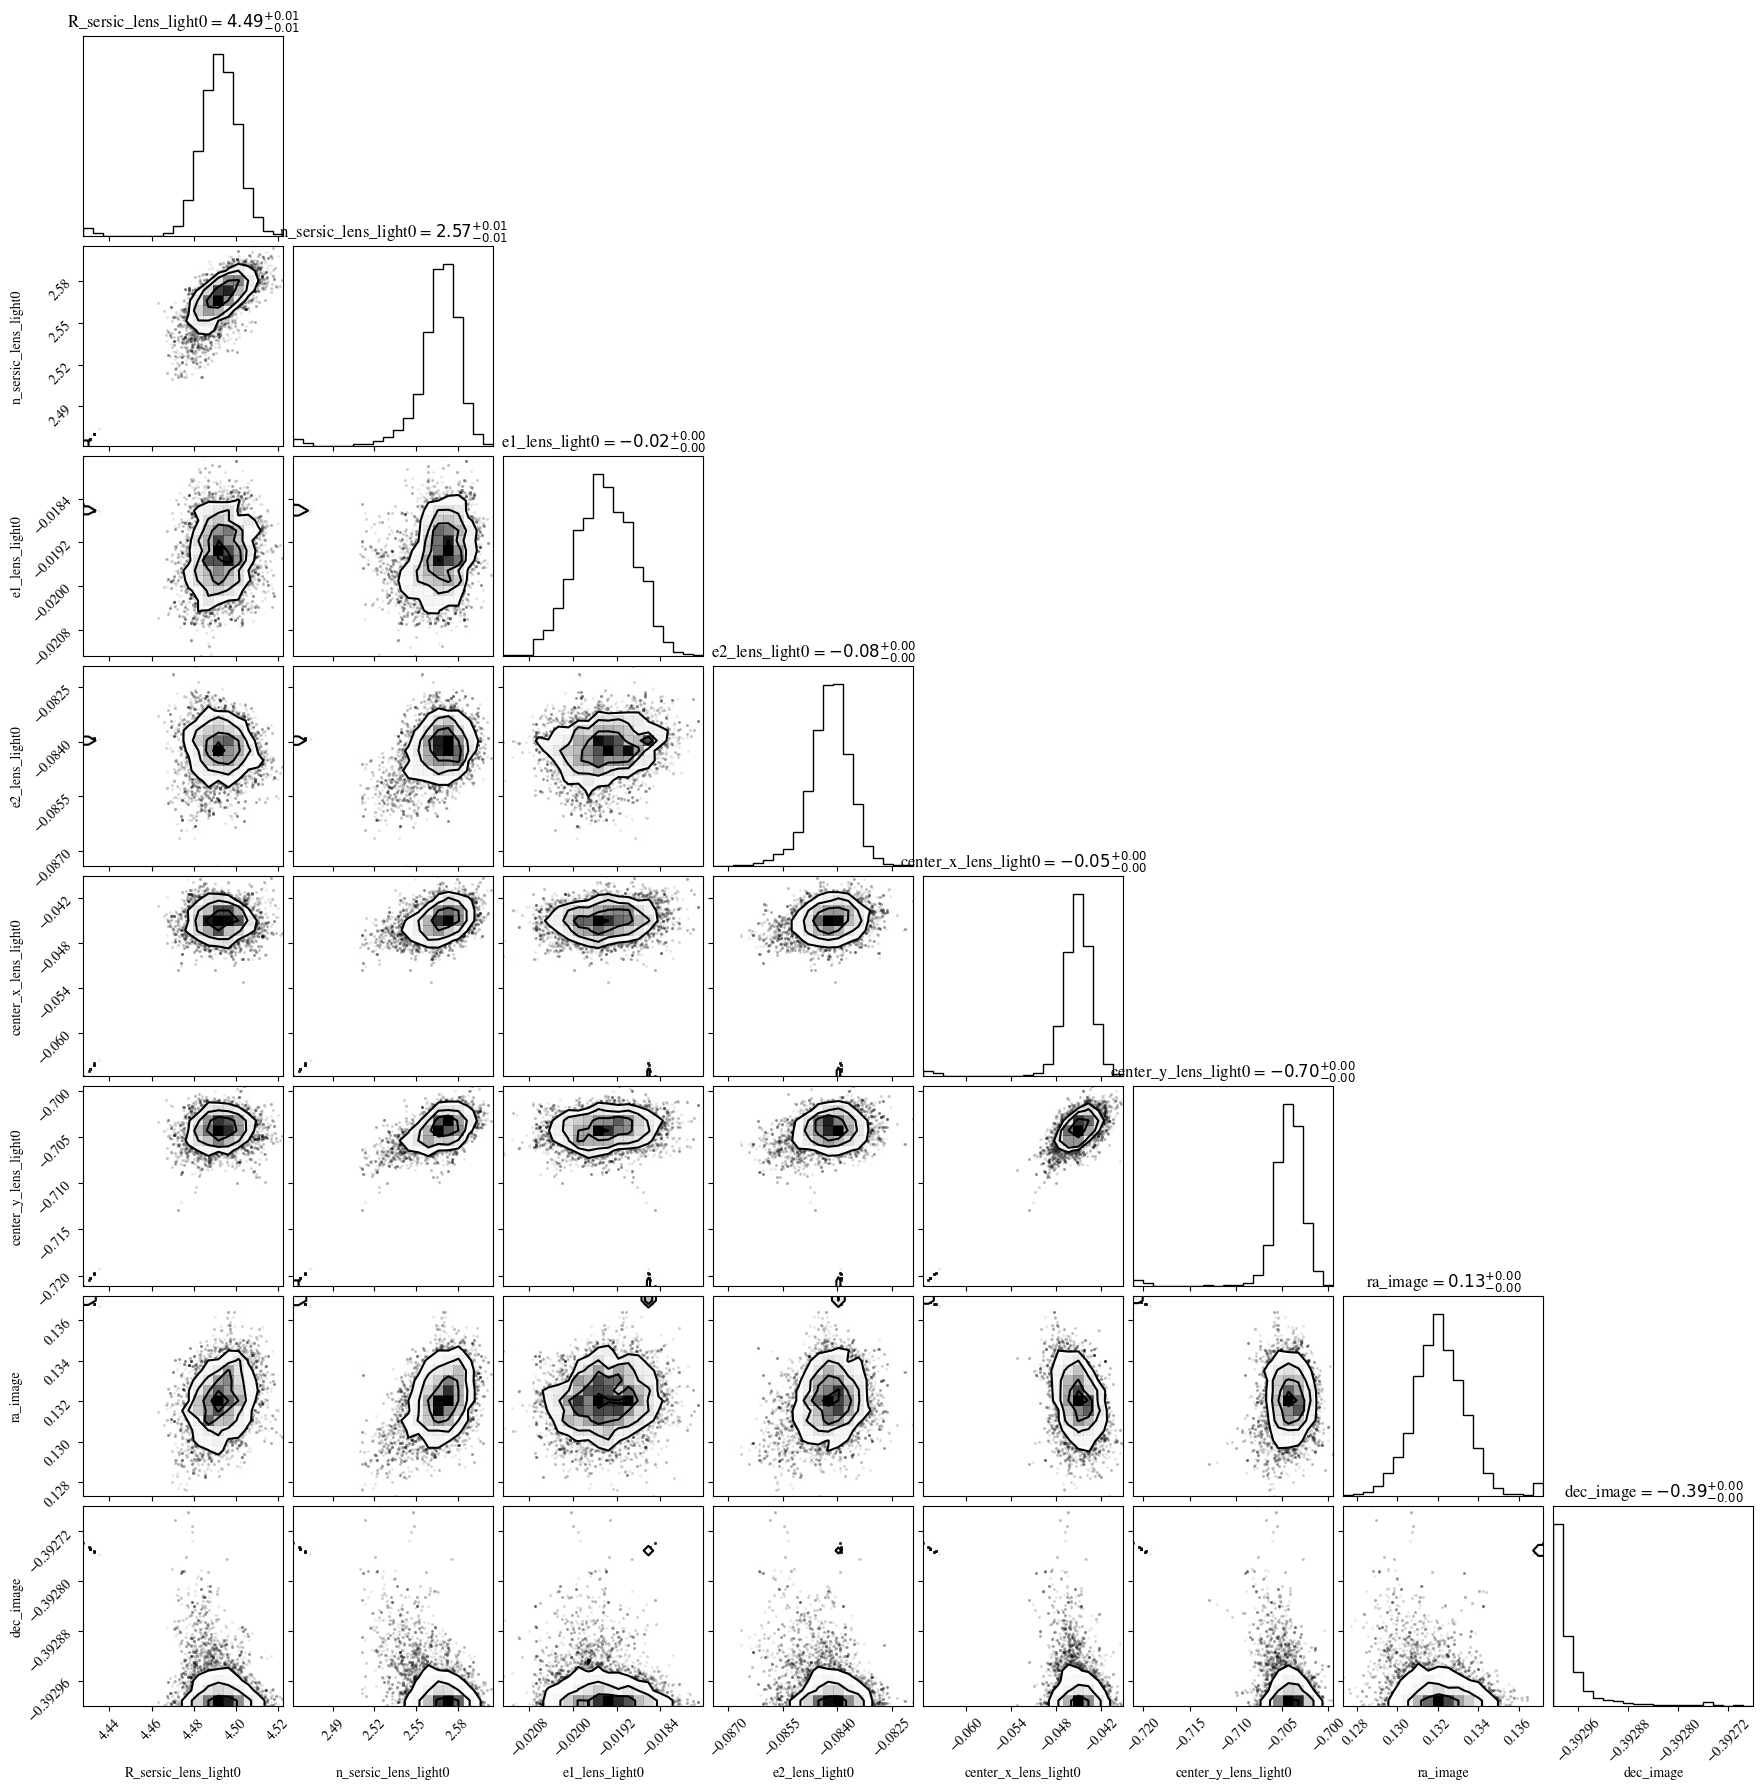

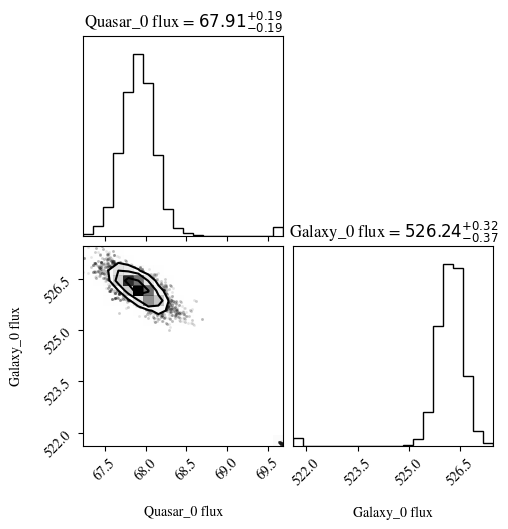

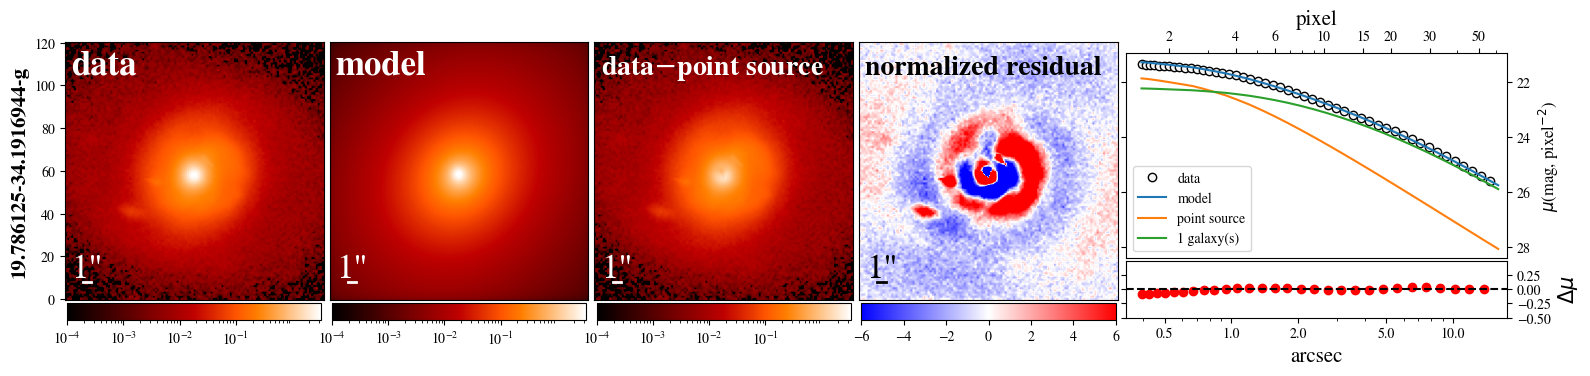

In [5]:
fit_object(
    pos=(19.7861250,-34.1916944), 
    img_path="data/GSN069/sky_g.fits",
    psf_path="data/GSN069/PSF_g.fits",
    additional_components="AGN",
    band="g",
    savefolder="data/GSN069/",
    fitting_level="deep",
    if_plot=True,
    )